# 07 — Gate 2 analysis: pool integrity, degeneracy verdict, T1 (spec v0.9.1 §2.9, §5, §7)

Runs AFTER `06_gate2_pool` completes all three runs. Kernel: `y2y-geo`.

## Pre-registered degeneracy verdict (frozen HERE, before the pool ran)

Computed on the **deduplicated** pool (prioritizr returns main solution + pool, so the incumbent
can appear twice), over **discretionary** cells only (locked PAs are selected in every solution
by construction and would dilute the denominator):

- `k_distinct` = number of distinct solutions among the ≤50 returned
- `frac_conditional` = share of ever-selected discretionary cells with 0 < f < 1
  (f = within-formulation frequency over distinct solutions)

| verdict | condition | consequence |
|---|---|---|
| **PLATEAU-RICH** | k_distinct ≥ 10 AND frac_conditional ≥ 5% | Claim A carries; proceed toward Gate 3 |
| **NEAR-BINARY** | k_distinct ≤ 3 OR frac_conditional < 1% | fail branch fires → pivot decision with the chat (§2.9) |
| **INTERMEDIATE** | anything else | numbers to the chat; decision there before Gate 3 |

In [1]:
# ---- bootstrap -----------------------------------------------------------------------------
import importlib, json, pathlib, sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook -- run from within the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc
for _m in (config, lc):
    importlib.reload(_m)

RUNS = {k: config.RESULTS_DIR / f"iter9_y2y_s0_{k}" for k in ("lp", "single", "pool")}
for k, d in RUNS.items():
    assert (d / "run_summary.json").exists(), f"{d.name} not solved yet -- run 06 first"
SUMM = {k: json.loads((d / "run_summary.json").read_text()) for k, d in RUNS.items()}
SC = json.loads((ROOT / "analyses/y2y/spec/scenarios_v1.json").read_text())
S0W, S0T = SC["S0_balanced"]["weights"], SC["S0_balanced"]["targets"]
AUDIT_OBJ = ROOT / "analyses" / "y2y" / "audit" / "audit_objects"
CONSTS = json.loads((AUDIT_OBJ / "audit_constants.json").read_text())

pu = lc.pu_mask()
assert int(pu.sum()) == SUMM["pool"]["n_planning_units"] == CONSTS["n_pu"]
with rasterio.open(config.HANDOFF_DIR / "mask_protected_areas.tif") as src:
    locked = src.read(1) == 1
assert int((locked & pu).sum()) == SUMM["pool"]["n_locked_in"], "locked-PA count mismatch"
print({k: f"{s['solve_seconds']:.0f}s / {s['n_alternatives']} sol" for k, s in SUMM.items()})

{'lp': '6516s / 1 sol', 'single': '55s / 1 sol', 'pool': '1799s / 50 sol'}


## §A — Pool integrity

Load all bands, deduplicate, and cross-check three independent paths: the engine's
`selection_frequency.tif` vs column sums; the engine's recorded per-solution objectives
(`solver_provenance`, added to the engine for Gate 2) vs objectives **recomputed exactly**
from `portfolio_representation.csv` (min-shortfall = Σ_f w_f · max(0, t_f − rel_held_f)/t_f);
and the objective span vs the 5% pool gap (the estimand's premise).

In [2]:
# ---- load the pool -> boolean matrix S (k x PU), dedup, frequency cross-check --------------
with rasterio.open(RUNS["pool"] / "portfolio.tif") as src:
    B = src.read(masked=True)                       # (k, H, W) uint8
K = B.shape[0]
S = (B.filled(0) > 0.5)[:, pu]                      # k x n_pu boolean
del B
assert K == SUMM["pool"]["n_alternatives"]

Sd, first_idx = np.unique(S, axis=0, return_index=True)
k_distinct = Sd.shape[0]
print(f"pool: {K} solutions returned, {k_distinct} DISTINCT "
      f"(prioritizr returns main + pool, so the incumbent can repeat)")

with rasterio.open(RUNS["pool"] / "selection_frequency.tif") as src:
    freq_engine = src.read(1, masked=True).filled(0)[pu].astype(int)
assert np.array_equal(freq_engine, S.sum(axis=0)), "selection_frequency.tif != column sums"
print("frequency cross-check: engine == recomputed (exact)")

f = Sd.mean(axis=0)                                 # within-formulation frequency over DISTINCT solutions
sel_sizes = S.sum(axis=1)
print(f"selected cells per solution: min {sel_sizes.min():,} / max {sel_sizes.max():,} "
      f"(budget {SUMM['pool']['budget_cells']:,})")

pool: 50 solutions returned, 50 DISTINCT (prioritizr returns main + pool, so the incumbent can repeat)
frequency cross-check: engine == recomputed (exact)
selected cells per solution: min 381,874 / max 381,874 (budget 381,874)


In [3]:
# ---- objectives: engine provenance vs exact recomputation from the representation CSV ------
def weight_of(feat):
    if feat in S0W:                     return float(S0W[feat])
    if feat == "human_modification":    return 1.0
    return 1.0 / 40.0                   # EFGs: locked foundation baseline

def target_of(feat):
    return float(S0T.get(feat, 1.0))

def objectives_from_csv(run_dir):
    rep = pd.read_csv(run_dir / "portfolio_representation.csv")
    out = {}
    for alt, df in rep.groupby("alternative"):
        obj = sum(weight_of(r.feature) * max(0.0, target_of(r.feature) - r.relative_held)
                  / target_of(r.feature) for r in df.itertuples())
        out[alt] = obj
    return pd.Series(out).sort_index()

obj_csv = objectives_from_csv(RUNS["pool"])
prov = SUMM["pool"].get("solver_provenance", {})
if "objective" in prov:
    obj_eng = np.atleast_1d(np.asarray(prov["objective"], dtype=float))
    n = min(len(obj_eng), len(obj_csv))
    dmax = float(np.abs(obj_eng[:n] - obj_csv.values[:n]).max())
    print(f"objective cross-check (engine vs CSV recompute): max |delta| = {dmax:.2e} "
          + ("OK" if dmax < 1e-5 else "-- MISMATCH, inspect before trusting either"))
else:
    print("no solver_provenance in run_summary (engine predates the field?) -- using CSV objectives")

best, worst = float(obj_csv.min()), float(obj_csv.max())
span = (worst - best) / best if best > 0 else np.nan
print(f"objective span: best {best:.6f} / worst {worst:.6f} -> {100*span:.2f}% of best "
      f"(pool gap 5%)")
if span > 0.05 + 1e-6:
    print("WARNING: span exceeds the pool gap -- a solution escaped the g-band; inspect")

# the certified single optimum should equal the pool's best (both at opt_gap 1e-4)
obj_single = objectives_from_csv(RUNS["single"])
print(f"single certified optimum {float(obj_single.iloc[0]):.6f} vs pool best {best:.6f} "
      f"(delta {abs(float(obj_single.iloc[0]) - best):.2e})")

objective cross-check (engine vs CSV recompute): max |delta| = 2.98e-05 -- MISMATCH, inspect before trusting either
objective span: best 5.362813 / worst 5.362830 -> 0.00% of best (pool gap 5%)
single certified optimum 5.362860 vs pool best 5.362813 (delta 4.66e-05)


In [4]:
# ---- SS B: the PRE-REGISTERED degeneracy verdict (rule frozen in the header, before the run) --
disc = ~locked[pu]                                   # discretionary planning units
union = (f > 0) & disc
frac_conditional = float(((f > 0) & (f < 1) & disc).sum() / max(union.sum(), 1))

Jm = np.nan
if k_distinct > 1:
    inter = (Sd.astype(np.float32) @ Sd.astype(np.float32).T)     # pairwise intersections
    sizes = Sd.sum(axis=1, dtype=np.float64)
    uni = sizes[:, None] + sizes[None, :] - inter
    Jp = inter / uni
    Jm = float(Jp[np.triu_indices(k_distinct, 1)].mean())

n_cond = int(((f > 0) & (f < 1) & disc).sum())
print(f"k_distinct = {k_distinct}  |  discretionary union {int(union.sum()):,} cells  |  "
      f"conditional (0<f<1) {n_cond:,} = {100*frac_conditional:.2f}%  |  mean pairwise Jaccard {Jm:.4f}")

if k_distinct >= 10 and frac_conditional >= 0.05:
    VERDICT = "PLATEAU-RICH -- Claim A carries; proceed toward Gate 3"
elif k_distinct <= 3 or frac_conditional < 0.01:
    VERDICT = "NEAR-BINARY -- fail branch fires; pivot decision with the chat (spec 2.9)"
else:
    VERDICT = "INTERMEDIATE -- numbers to the chat; decision there before Gate 3"
print(f"\nVERDICT: {VERDICT}")

k_distinct = 50  |  discretionary union 190,926 cells  |  conditional (0<f<1) 165 = 0.09%  |  mean pairwise Jaccard 0.9999

VERDICT: NEAR-BINARY -- fail branch fires; pivot decision with the chat (spec 2.9)


## §C — T1 intended-vs-realized (on the certified single solve)

Realized capture per feature (biomass headline vs the measured anchors: **25.9%** co-capture
floor / 41.3% a0 / **49.7%** a1 ceiling); realized two-regime influence shares vs the intended
0.25-per-block profile (the iterate-once rule goes to the chat only if the miss is large); and
the **θ-tail capture rate for every continuous feature** — the standing T1/E7 diagnostic, with
the pre-stated biomass expectation (high at w ≈ 0.199).

In [5]:
# ---- realized capture + influence + theta-tail capture (single certified solve) ------------
import ensemble_core as ec
importlib.reload(ec)
sel1 = np.nan_to_num(ec._alloc(RUNS["single"] / "portfolio.tif")) > 0.5

rep1 = pd.read_csv(RUNS["single"] / "portfolio_representation.csv").set_index("feature")["relative_held"]
theta = config.AUDIT["theta"]
rows = []
for feat in lc.continuous_features():
    v = lc._read(config.HANDOFF_DIR / f"{feat}.tif")
    cmin, cmax, _ = lc.leverage_of(v[pu])
    t = target_of(feat); w = weight_of(feat)
    held = float(rep1[feat])
    tail = pu & (np.nan_to_num(v, nan=-1.0) >= theta * float(np.nanmean(v[pu])))
    tmass = float(np.nansum(v[tail]))
    rows.append(dict(
        feature=feat, w=w, t=t, capture=held,
        realized_swing=w * (min(held, t) - cmin) / t,
        tail_pct_area=100 * tail.sum() / pu.sum(),
        tail_capture_mass=(float(np.nansum(v[tail & sel1])) / tmass) if tmass > 0 else np.nan,
    ))
T1 = pd.DataFrame(rows).set_index("feature")
blocked = [ft for fts in config.BLOCKS.values() for ft in fts]
T1["realized_share"] = np.where(
    T1.index.isin(blocked), T1.realized_swing / T1.loc[blocked, "realized_swing"].sum(), np.nan)
T1["intended_share"] = pd.Series(SC["S0_balanced"]["intended_shares"]).reindex(T1.index)
T1["share_miss"] = T1.realized_share - T1.intended_share
print(T1.round(4).to_string())
print(f"\nbiomass capture {100*T1.loc['irrecoverable_carbon_biomass','capture']:.1f}% "
      f"(anchors: 25.9 floor / 41.3 a0 / 49.7 a1)  |  "
      f"biomass theta-tail mass capture {T1.loc['irrecoverable_carbon_biomass','tail_capture_mass']:.3f} "
      f"(pre-stated expectation: high)")
print(f"largest |share miss| among blocked features: {T1.share_miss.abs().max():.4f} "
      f"(iterate-once rule -> chat only if large)")

                                   w      t  capture  realized_swing  tail_pct_area  tail_capture_mass  realized_share  intended_share  share_miss
feature                                                                                                                                           
human_modification            1.0000  1.000   0.2992          0.0272         0.0000                NaN             NaN             NaN         NaN
transboundary_connectivity    0.6693  1.000   0.3341          0.1628         0.2009             0.9795          0.0978          0.1250     -0.0272
climate_corridors             1.1714  1.000   0.2603          0.1226         0.0000                NaN          0.0736          0.1250     -0.0514
climate_type_macrorefugia     1.4600  1.000   0.4521          0.4624         0.4791             1.0000          0.2777          0.2500      0.0277
irrecoverable_carbon_biomass  0.1986  1.000   0.3103          0.0613         1.1720             0.4253          0.0368

In [6]:
# ---- SS D: LP-twin tightness (extends the Gate-0 record to the S0 formulation) -------------
lp = ec._alloc(RUNS["lp"] / "portfolio.tif")
frac = np.nan_to_num(lp)
integral = float(((frac < 1e-6) | (frac > 1 - 1e-6) | ~np.isfinite(lp)).mean())
Slp = frac > 0.5
j = float((Slp & sel1).sum() / max((Slp | sel1).sum(), 1))
rl = pd.read_csv(RUNS["lp"] / "portfolio_representation.csv").set_index("feature")["relative_held"]
dcap = float((rl - rep1).abs().max())
print(f"LP integrality {100*integral:.2f}% | LP-vs-MILP Jaccard {j:.4f} | "
      f"max |capture delta| {dcap:.4f}")

LP integrality 100.00% | LP-vs-MILP Jaccard 0.9957 | max |capture delta| 0.0006


## §E — E4 seed + the spec §10 run contract

`runs/gate2_s0_ref/solutions.npz` (PU-indexed boolean matrix, within-formulation frequency,
objectives) + `formulation_audit.json` — the k=50/g=5% grid point E4 subsamples later (Gurobi's pool
is quality-sorted, so k=10/30 are prefixes of this pool). Frequency-surface figure →
`figures/`.

wrote analyses/y2y/runs/gate2_s0_ref/solutions.npz + cell_audit.json


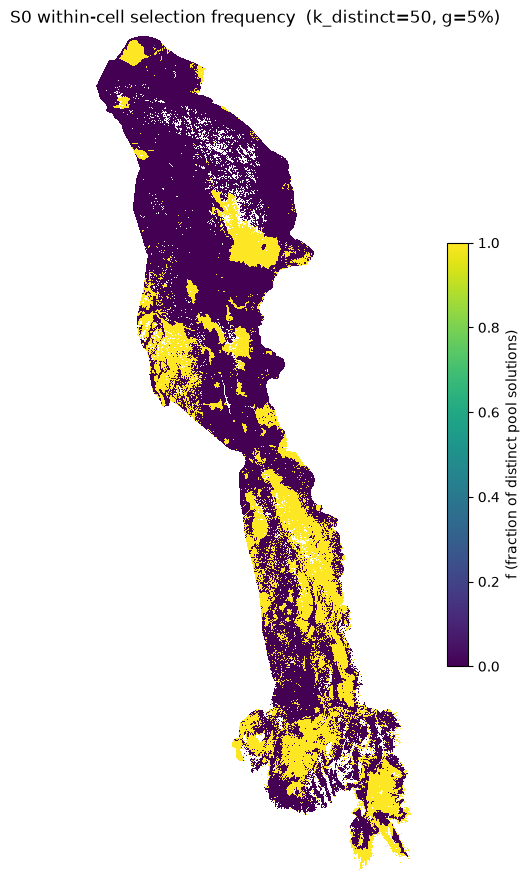

figure -> analyses/y2y/figures/gate2_s0_frequency.png


In [7]:
# ---- write the E4 seed + formulation audit --------------------------------------------------------
run_dir = ROOT / "analyses" / "y2y" / "runs" / "gate2_s0_ref"
run_dir.mkdir(parents=True, exist_ok=True)
np.savez_compressed(run_dir / "solutions.npz",
                    S=Sd.astype(np.uint8), f=f.astype(np.float32),
                    objectives_csv=obj_csv.values.astype(float),
                    locked=locked[pu], pu_shape=np.array(pu.shape), pu_mask=pu)
audit = dict(
    formulation_id="gate2_s0_ref", scenario="S0_balanced",
    weights=S0W, targets=S0T,
    k_requested=50, k_returned=int(K), k_distinct=int(k_distinct),
    pool_gap=0.05, opt_gap=1e-4,
    objective_best=best, objective_worst=worst, objective_span=span,
    frac_conditional=frac_conditional, mean_pairwise_jaccard=None if np.isnan(Jm) else Jm,
    verdict=VERDICT,
    solve_seconds={k: SUMM[k]["solve_seconds"] for k in SUMM},
    layer_sha256=CONSTS["layer_sha256"],
    created_utc=datetime.now(timezone.utc).isoformat(),
)
(run_dir / "formulation_audit.json").write_text(json.dumps(audit, indent=2))
print(f"wrote {run_dir.relative_to(ROOT)}/solutions.npz + formulation_audit.json")

fig_dir = ROOT / "analyses" / "y2y" / "figures"
fig_dir.mkdir(exist_ok=True)
F = np.full(pu.shape, np.nan, dtype=np.float32)
F[pu] = f
fig, ax = plt.subplots(figsize=(7, 11))
im = ax.imshow(F, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
ax.set_title(f"S0 within-formulation selection frequency  (k_distinct={k_distinct}, g=5%)")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.5, label="f (fraction of distinct pool solutions)")
fig.savefig(fig_dir / "gate2_s0_frequency.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"figure -> {(fig_dir / 'gate2_s0_frequency.png').relative_to(ROOT)}")

## Next

Bring to the chat: the §B verdict line, the §A objective-span line, §C's T1 table (biomass
headline + θ-tail rates + share misses), the pool-cost numbers from 06, and §D's tightness.
The Gate-2 decision — Gate 3 manifest freeze vs pivot — is made there. Fill results_log R6
with these numbers in the same session.